In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller

# Load the dataset
# Note: Adjust the path based on your directory structure
df = pd.read_csv('../data/BrentOilPrices.csv')

# Use format='mixed' to handle "20-May-87" and "Apr 22, 2020" in the same column
df['Date'] = pd.to_datetime(df['Date'], format='mixed')

# It's good practice to check if any dates failed to parse (NaT)
if df['Date'].isnull().any():
    print("Warning: Some dates could not be parsed.")
    # Optional: df = df.dropna(subset=['Date'])

# Set index and sort
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)

print("Data successfully loaded and sorted!")


print(df.head())
print(df.info())

Data successfully loaded and sorted!
            Price
Date             
1987-05-20  18.63
1987-05-21  18.45
1987-05-22  18.55
1987-05-25  18.60
1987-05-26  18.63
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9011 entries, 1987-05-20 to 2022-11-14
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Price   9011 non-null   float64
dtypes: float64(1)
memory usage: 140.8 KB
None


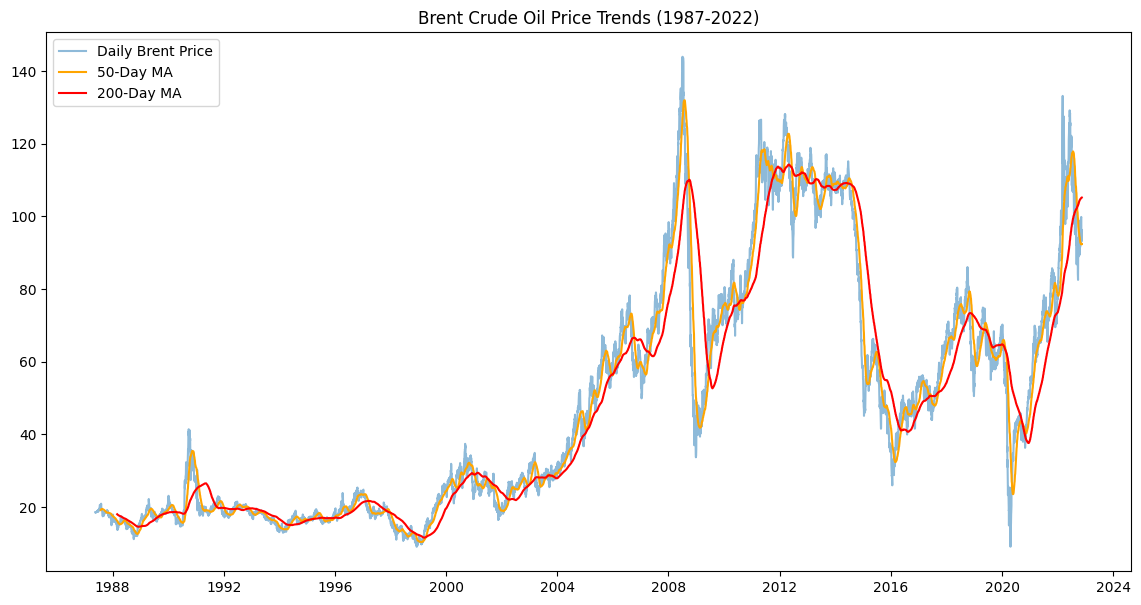

In [7]:
plt.figure(figsize=(14, 7))
plt.plot(df['Price'], label='Daily Brent Price', alpha=0.5)
plt.plot(df['Price'].rolling(window=50).mean(), label='50-Day MA', color='orange')
plt.plot(df['Price'].rolling(window=200).mean(), label='200-Day MA', color='red')
plt.title('Brent Crude Oil Price Trends (1987-2022)')
plt.legend()
plt.show()

In [9]:
def check_stationarity(series):
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {result[1]}')
    if result[1] <= 0.05:
        print("Data is stationary (Reject Null Hypothesis)")
    else:
        print("Data is non-stationary (Fail to Reject Null Hypothesis)")

print("Testing Raw Price Series:")
check_stationarity(df['Price'])

Testing Raw Price Series:
ADF Statistic: -1.9938560113924675
p-value: 0.28927350489340287
Data is non-stationary (Fail to Reject Null Hypothesis)


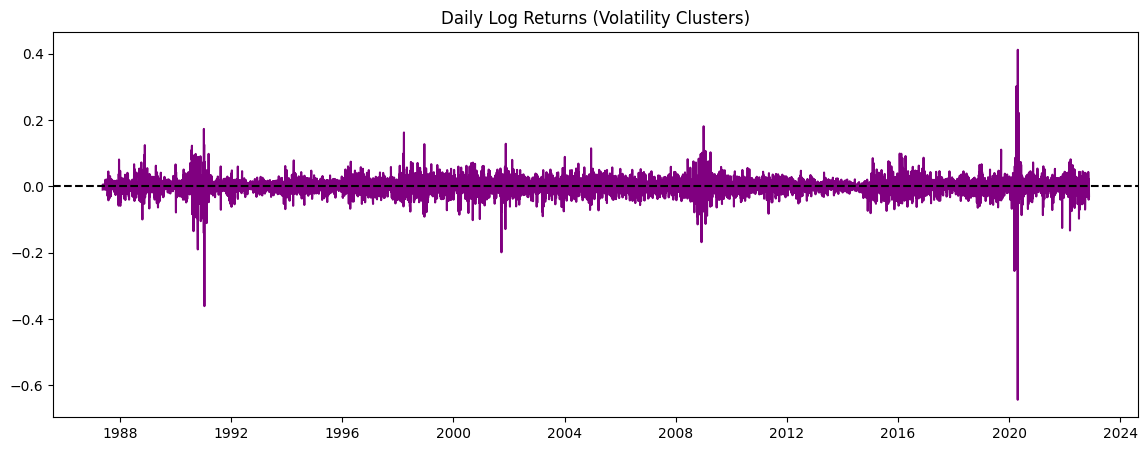


Testing Log Returns for Stationarity:
ADF Statistic: -16.42711349448591
p-value: 2.4985801611427818e-29
Data is stationary (Reject Null Hypothesis)


In [10]:
# Calculate Log Returns
df['Log_Return'] = np.log(df['Price'] / df['Price'].shift(1))

plt.figure(figsize=(14, 5))
plt.plot(df['Log_Return'], color='purple')
plt.title('Daily Log Returns (Volatility Clusters)')
plt.axhline(0, color='black', linestyle='--')
plt.show()

print("\nTesting Log Returns for Stationarity:")
check_stationarity(df['Log_Return'])

Choice of Log Returns: Because the price series is non-stationary, we should perform change point detection on returns or use a model that explicitly accounts for shifts in the price mean.
Likelihood Function: Since oil returns often have "fat tails" (extreme spikes during wars/recessions), we might consider a Student-T distribution instead of a Normal distribution for our Bayesian model.
The Switch Point: The volatility clusters seen in the Log Returns plot align with the events in our external_events.csv, suggesting that 
τ(the switch point) will likely fall near those dates.
